# 3. Compare saved XGBoost and SAP RPT 1.6 results

## Goal

Compare both models on the **same 128 held-out synthetic invoices** from the main TechEd dataset. Its first 1,024 rows contain 187 fraud labels; the test set contains 22 fraud labels. This notebook reads saved predictions and verified BTP provenance. It never trains a model or calls BTP.

XGBoost uses fraud class weighting and a 0.5 decision threshold; RPT returns top-1 classes from labeled context. The previous Playground export belongs to a different synthetic-label scenario and is excluded from this comparison. RPT ROC AUC remains blank because the saved top-1 response does not supply a positive-class score for every invoice.

## 1. Validate the dataset and XGBoost predictions

In [1]:
import hashlib
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / "data/synthetic_invoices/payment_behavior.csv").exists())
DATA = ROOT / "data/synthetic_invoices"
TARGETS = ("paid_late", "is_fraud")
CONTEXT_ROWS = 1024
PREDICTION_ROWS = 128
source = pd.read_csv(DATA / "payment_behavior.csv")
test = source.iloc[CONTEXT_ROWS:].reset_index(drop=True)
xgb = pd.read_csv(DATA / "xgboost_results.csv")
assert len(source) == 1152 and len(test) == len(xgb) == PREDICTION_ROWS
assert source.invoice_id.is_unique and xgb.invoice_id.is_unique
assert int(source.is_fraud.iloc[:CONTEXT_ROWS].sum()) == 187
assert int(test.is_fraud.sum()) == 22 and int(test.paid_late.sum()) == 51
assert xgb.invoice_id.tolist() == test.invoice_id.tolist()
for target in TARGETS:
    assert xgb[f"actual_{target}"].tolist() == test[target].tolist()
    assert xgb[f"predicted_{target}"].isin([0, 1]).all()
    assert xgb[f"probability_{target}"].between(0, 1).all()
print(f"Validated XGBoost on {len(test)} test invoices: {int(test.paid_late.sum())} paid late, {int(test.is_fraud.sum())} fraud.")

Validated XGBoost on 128 test invoices: 51 paid late, 22 fraud.


## 2. Validate the saved direct BTP result

The public metadata records model name, run time, and hashes of the RPT request and scored results. The raw BTP response and local credentials are excluded from the published repository.

In [2]:
btp_path = DATA / "rpt16_results.csv"
metadata_path = DATA / "rpt16_run_metadata.json"
request_path = DATA / "rpt16_request.json"
if not btp_path.exists() or not metadata_path.exists():
    raise FileNotFoundError("Saved BTP results are missing. Run rpt_btp_run.ipynb with RUN_LIVE_RPT=True to create them.")
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
assert metadata["source"] == "btp_deployment"
assert metadata["request_sha256"] == hashlib.sha256(request_path.read_bytes()).hexdigest()
assert metadata["results_sha256"] == hashlib.sha256(btp_path.read_bytes()).hexdigest()
assert metadata["test_rows"] == PREDICTION_ROWS
rpt = pd.read_csv(btp_path)
assert len(rpt) == PREDICTION_ROWS and rpt.invoice_id.is_unique
assert rpt.invoice_id.tolist() == test.invoice_id.tolist()
for target in TARGETS:
    assert rpt[f"actual_{target}"].tolist() == test[target].tolist()
    assert rpt[f"predicted_{target}"].isin([0, 1]).all()
    assert rpt[f"confidence_{target}"].between(0, 1).all()
print(f"Validated direct {metadata['model_configured']} BTP result from {metadata['run_at_utc']} (UTC).")

Validated direct sap-rpt-1.6-large BTP result from 2026-10-03T22:17:05.746027+00:00 (UTC).


## 3. Calculate comparable metrics

Accuracy, precision, and recall use predicted class labels. XGBoost ROC AUC uses its saved class-1 probabilities. RPT ROC AUC is not available from this top-1 response. For fraud, show true positives and false alarms alongside percentages.

In [3]:
metric_rows = []
confusion_rows = []
for model_name, frame in [("XGBoost", xgb), ("SAP RPT 1.6 BTP", rpt)]:
    for target in TARGETS:
        actual = frame[f"actual_{target}"]
        predicted = frame[f"predicted_{target}"]
        tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
        metric_rows.append({
            "Model": model_name, "Target": target, "Positive cases": int(actual.sum()),
            "Accuracy": accuracy_score(actual, predicted),
            "Precision": precision_score(actual, predicted, zero_division=0),
            "Recall": recall_score(actual, predicted, zero_division=0),
            "ROC AUC": roc_auc_score(actual, frame[f"probability_{target}"]) if model_name == "XGBoost" else float("nan"),
        })
        confusion_rows.append({"Model": model_name, "Target": target,
                               "True positives": int(tp), "False positives": int(fp),
                               "False negatives": int(fn), "True negatives": int(tn)})
metrics = pd.DataFrame(metric_rows).set_index(["Model", "Target"])
confusion = pd.DataFrame(confusion_rows).set_index(["Model", "Target"])
display(metrics.round(3))
display(confusion)

Positive cases  Accuracy  Precision  Recall  \
Model           Target                                                   
XGBoost         paid_late              51     0.656      0.561   0.627   
                is_fraud               22     0.875      0.625   0.682   
SAP RPT 1.6 BTP paid_late              51     0.711      0.630   0.667   
                is_fraud               22     0.867      0.667   0.455   

                           ROC AUC  
Model           Target              
XGBoost         paid_late    0.724  
                is_fraud     0.804  
SAP RPT 1.6 BTP paid_late      NaN  
                is_fraud       NaN

True positives  False positives  False negatives  \
Model           Target                                                        
XGBoost         paid_late              32               25               19   
                is_fraud               15                9                7   
SAP RPT 1.6 BTP paid_late              34               20               17   
                is_fraud               10                5               12   

                           True negatives  
Model           Target                     
XGBoost         paid_late              52  
                is_fraud               97  
SAP RPT 1.6 BTP paid_late              57  
                is_fraud              101

## 4. Visualize the trade-off

The left panel compares late-payment metrics. The right panel shows how many of the 22 fraud cases each model found and how many non-fraud invoices it flagged by mistake.

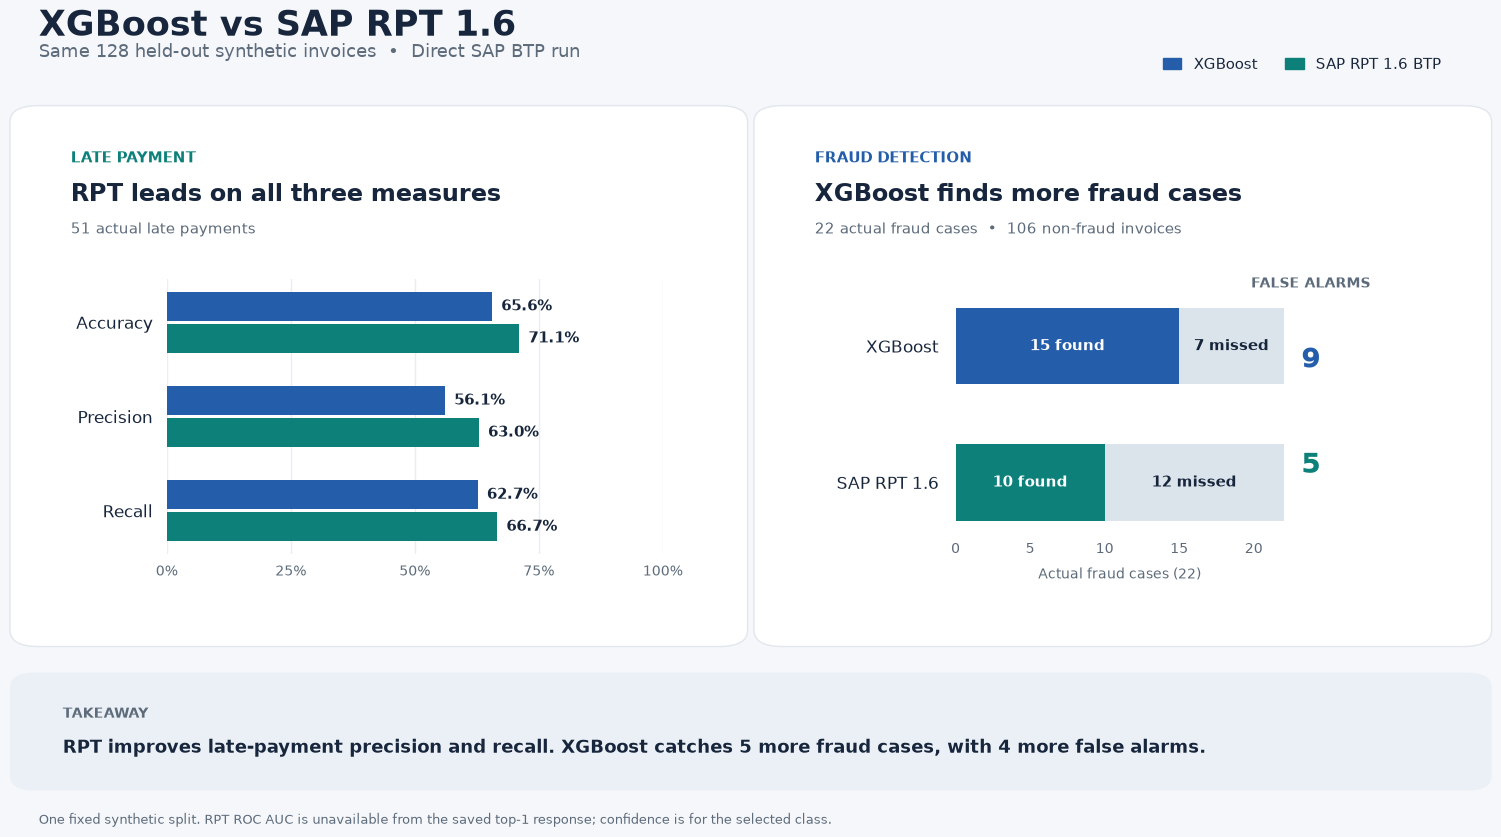

Saved notebooks/saved_results_comparison.png


In [4]:
from matplotlib.patches import FancyBboxPatch, Patch

COLORS = {"XGBoost": "#245EAA", "SAP RPT 1.6 BTP": "#0E807A"}
INK = "#17263C"
MUTED = "#5D6B7B"
PANEL = "#FFFFFF"
BACKGROUND = "#F5F7FA"
MISSED = "#DCE4EB"

fig = plt.figure(figsize=(16, 9), facecolor=BACKGROUND)
fig.text(.055, .935, "XGBoost vs SAP RPT 1.6", fontsize=25, color=INK, weight="bold", va="top")
fig.text(.055, .882, "Same 128 held-out synthetic invoices  •  Direct SAP BTP run", fontsize=13, color=MUTED)
fig.legend(handles=[Patch(color=COLORS[name], label=name) for name in COLORS],
           loc="upper right", bbox_to_anchor=(.94, .897), ncol=2, frameon=False,
           fontsize=11, labelcolor=INK, handlelength=1.2, columnspacing=1.8)

for x, width in ((.045, .445), (.510, .445)):
    fig.add_artist(FancyBboxPatch((x, .235), width, .585,
                   boxstyle="round,pad=0.008,rounding_size=0.018",
                   # Figure-level cards need a negative z-order; otherwise they cover the plotted bars.
                   transform=fig.transFigure, facecolor=PANEL, edgecolor="#E1E7ED", linewidth=1, zorder=-10))

fig.text(.075, .765, "LATE PAYMENT", color=COLORS["SAP RPT 1.6 BTP"], fontsize=11, weight="bold")
fig.text(.075, .722, "RPT leads on all three measures", color=INK, fontsize=17, weight="bold")
fig.text(.075, .686, "51 actual late payments", color=MUTED, fontsize=11)

late_ax = fig.add_axes([.135, .330, .310, .305], facecolor="none")
metric_labels = ["Accuracy", "Precision", "Recall"]
for offset, name in ((.17, "XGBoost"), (-.17, "SAP RPT 1.6 BTP")):
    values = [metrics.loc[(name, "paid_late"), measure] for measure in metric_labels]
    bars = late_ax.barh([2 + offset, 1 + offset, 0 + offset], values,
                        height=.31, color=COLORS[name], zorder=3)
    for bar, value in zip(bars, values):
        late_ax.text(value + .018, bar.get_y() + bar.get_height()/2, f"{value:.1%}",
                     va="center", fontsize=11, color=INK, weight="bold")
late_ax.set_yticks([2, 1, 0], metric_labels, color=INK, fontsize=12)
late_ax.set_xlim(0, 1)
late_ax.set_xticks([0, .25, .5, .75, 1], ["0%", "25%", "50%", "75%", "100%"])
late_ax.tick_params(axis="x", colors=MUTED, labelsize=10, length=0, pad=8)
late_ax.tick_params(axis="y", length=0, pad=10)
late_ax.xaxis.grid(True, color="#E9EEF2", linewidth=1)
late_ax.set_axisbelow(True)
for spine in late_ax.spines.values(): spine.set_visible(False)

fig.text(.540, .765, "FRAUD DETECTION", color=COLORS["XGBoost"], fontsize=11, weight="bold")
fig.text(.540, .722, "XGBoost finds more fraud cases", color=INK, fontsize=17, weight="bold")
fig.text(.540, .686, "22 actual fraud cases  •  106 non-fraud invoices", color=MUTED, fontsize=11)
fig.text(.850, .626, "FALSE ALARMS", color=MUTED, fontsize=10, weight="bold", ha="center")

fraud_ax = fig.add_axes([.628, .355, .205, .260], facecolor="none")
for row, name in ((1, "XGBoost"), (0, "SAP RPT 1.6 BTP")):
    counts = confusion.loc[(name, "is_fraud")]
    found = int(counts["True positives"])
    missed = int(counts["False negatives"])
    false_alarms = int(counts["False positives"])
    fraud_ax.barh(row, found, height=.56, color=COLORS[name], zorder=3)
    fraud_ax.barh(row, missed, left=found, height=.56, color=MISSED, zorder=3)
    fraud_ax.text(found/2, row, f"{found} found", ha="center", va="center",
                  color="white", fontsize=11, weight="bold")
    fraud_ax.text(found + missed/2, row, f"{missed} missed", ha="center", va="center",
                  color=INK, fontsize=11, weight="bold")
    fig.text(.850, .545 if row == 1 else .428, str(false_alarms),
             color=COLORS[name], fontsize=20, weight="bold", ha="center", va="center")
fraud_ax.set_yticks([1, 0], ["XGBoost", "SAP RPT 1.6"], fontsize=12, color=INK)
fraud_ax.set_xlim(0, 22)
fraud_ax.set_xticks([0, 5, 10, 15, 20])
fraud_ax.tick_params(axis="x", colors=MUTED, labelsize=10, length=0, pad=8)
fraud_ax.tick_params(axis="y", length=0, pad=12)
fraud_ax.set_xlabel("Actual fraud cases (22)", color=MUTED, fontsize=10, labelpad=8)
for spine in fraud_ax.spines.values(): spine.set_visible(False)

fig.add_artist(FancyBboxPatch((.045, .075), .910, .115,
               boxstyle="round,pad=0.008,rounding_size=0.016",
               transform=fig.transFigure, facecolor="#EAF0F5", edgecolor="none", zorder=-10))
fig.text(.070, .148, "TAKEAWAY", fontsize=10, color=MUTED, weight="bold")
fig.text(.070, .109,
         "RPT improves late-payment precision and recall. XGBoost catches 5 more fraud cases, with 4 more false alarms.",
         fontsize=13, color=INK, weight="bold")
fig.text(.055, .030,
         "One fixed synthetic split. RPT ROC AUC is unavailable from the saved top-1 response; confidence is for the selected class.",
         fontsize=9.5, color=MUTED)

chart_path = ROOT / "notebooks/saved_results_comparison.png"
fig.savefig(chart_path, dpi=250, facecolor=BACKGROUND)
plt.show()
print(f"Saved {chart_path.relative_to(ROOT)}")

## Takeaways

On this 128-invoice synthetic test set, SAP RPT 1.6 has higher late-payment accuracy (71.1% versus 65.6%) and recall (66.7% versus 62.7%). For fraud, XGBoost finds 15 of 22 cases with 9 false alarms; RPT finds 10 of 22 with 5 false alarms. XGBoost has higher fraud recall, while RPT has fewer false alarms and slightly higher fraud precision. The BTP top-1 response does not support a comparable ROC AUC. This fixed synthetic split does not establish production performance.